# Eksperimen Analisis Sentimen Review Aplikasi Gojek

**Nama Siswa:** Vigian Agus Isenaeni
**Dataset:** Review aplikasi Gojek dari Google Play Store  
**Domain:** Layanan ride-hailing & on-demand  
**Label:** 3 kelas — `negatif`, `netral`, `positif`

---

## Ringkasan Pipeline
1. Perkenalan Dataset  
2. Import Library  
3. Memuat Dataset  
4. Exploratory Data Analysis (EDA)  
5. Data Preprocessing  

# 1. Perkenalan Dataset

Dataset yang digunakan adalah kumpulan **review berbahasa Indonesia** dari aplikasi **Gojek** yang di-scrape dari Google Play Store.

| Atribut | Detail |
|---------|--------|
| **Sumber** | Google Play Store (scraping) |
| **Bahasa** | Indonesia (dengan banyak slang) |
| **Jumlah baris** | ~35.000 |
| **Fitur utama** | `content` (teks review), `score` (rating 1–5), `label` (sentimen) |
| **Kelas label** | `negatif` (0), `netral` (1), `positif` (2) |

Dataset ini memiliki karakteristik khas teks informal Indonesia:  
- Banyak singkatan dan slang (`bgt`, `ngga`, `udh`, `lemot`)  
- Kata berulang untuk penekanan (`baguuus`, `ramahhhh`)  
- Campur kode dengan Bahasa Inggris (`good`, `ok`, `bad`)  
- Tanda baca berlebih (`!!`, `...`)  
- Emoji dan karakter khusus

# 2. Import Library

In [24]:
# ============================================================
# Standard Library
# ============================================================
import re
import json
import string
import random
import time
from pathlib import Path
from collections import Counter

# ============================================================
# Data Processing
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualisasi
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ============================================================
# NLP Bahasa Indonesia
# ============================================================
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ============================================================
# Machine Learning
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# Deep Learning
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, LSTM, Embedding, Dropout, Bidirectional,
    SpatialDropout1D, Conv1D, GlobalMaxPooling1D,
    GlobalAveragePooling1D, Concatenate, Input,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"Numpy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")

TensorFlow  : 2.16.1
Numpy       : 1.26.4
Pandas      : 2.2.3


# 3. Memuat Dataset

In [25]:
# Sesuaikan path dataset dengan lokasi file di sistem Anda
DATA_PATH = Path("../base_datasets_and_model/dataset_sentimen.csv")

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["content", "label"]).copy()
df["content"] = df["content"].astype(str)

print(f"Shape dataset: {df.shape}")
print(f"Kolom        : {list(df.columns)}")
df.head(10)

Shape dataset: (35000, 5)
Kolom        : ['username', 'score', 'content', 'tanggal', 'label']


,username,score,content,tanggal,label
0,Pengguna Google,5,Good,2026-05-18 21:39:53,positif
1,Pengguna Google,5,Jelek,2026-05-18 21:39:11,positif
2,Pengguna Google,1,pelayanan pada lama,2026-05-18 21:34:54,negatif
3,Pengguna Google,5,sangat bermanfaat,2026-05-18 21:26:54,positif
4,Pengguna Google,5,Kenapa nomor saya tiap daftar gopayletter sela...,2026-05-18 20:53:05,positif
5,Pengguna Google,1,tarif terlalu tinggi,2026-05-18 20:51:45,negatif
6,Pengguna Google,1,harus verifikasi email tapi link email juga ti...,2026-05-18 20:46:54,negatif
7,Pengguna Google,4,"gojek makin hari makin mahal aja, udah gak kay...",2026-05-18 20:34:42,positif
8,Pengguna Google,5,driver nya baik-baik,2026-05-18 20:27:34,positif
9,Pengguna Google,1,apk gk jls titik gk sesuai mendingan pake grab...,2026-05-18 20:23:50,negatif


In [26]:
# Informasi dasar dataset
print("=== INFO DATASET ===")
df.info()
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DUPLIKAT ===")
print(f"Jumlah baris duplikat: {df.duplicated(subset=['content']).sum()}")

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   username  35000 non-null  object
 1   score     35000 non-null  int64 
 2   content   35000 non-null  object
 3   tanggal   35000 non-null  object
 4   label     35000 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB

=== MISSING VALUES ===
username    0
score       0
content     0
tanggal     0
label       0
dtype: int64

=== DUPLIKAT ===
Jumlah baris duplikat: 9694


# 4. Exploratory Data Analysis (EDA)

Pada tahap ini kita akan memahami karakteristik dataset melalui:
- Distribusi label
- Distribusi panjang teks
- Distribusi rating (score)
- Word cloud per kelas
- Kata paling umum per kelas

Distribusi label:
label
positif    22364
negatif    11251
netral      1385
Name: count, dtype: int64

Rasio (%):
label
positif    63.9
negatif    32.1
netral      4.0
Name: count, dtype: float64


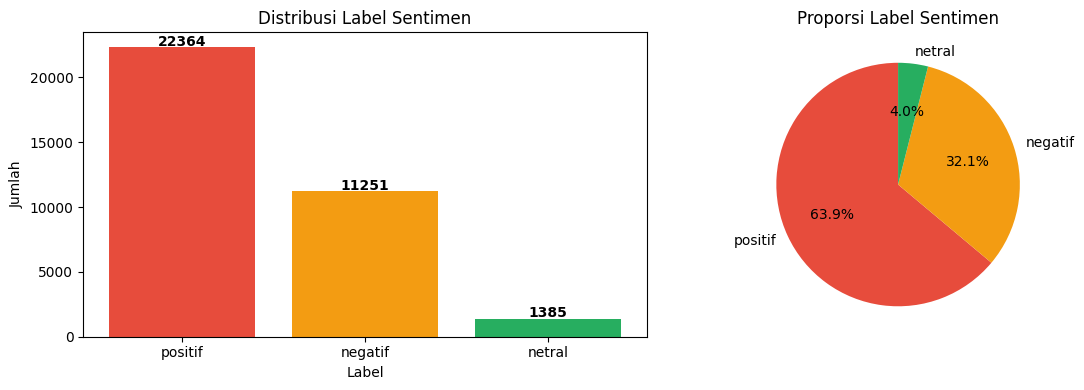

In [27]:
# --- 4.1 Distribusi Label ---
label_counts = df["label"].value_counts()
print("Distribusi label:")
print(label_counts)
ratio = label_counts / len(df) * 100

print("\nRasio (%):")
print(ratio.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ["#e74c3c", "#f39c12", "#27ae60"]
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title("Distribusi Label Sentimen")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Jumlah")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Proporsi Label Sentimen")

plt.tight_layout()
plt.show()

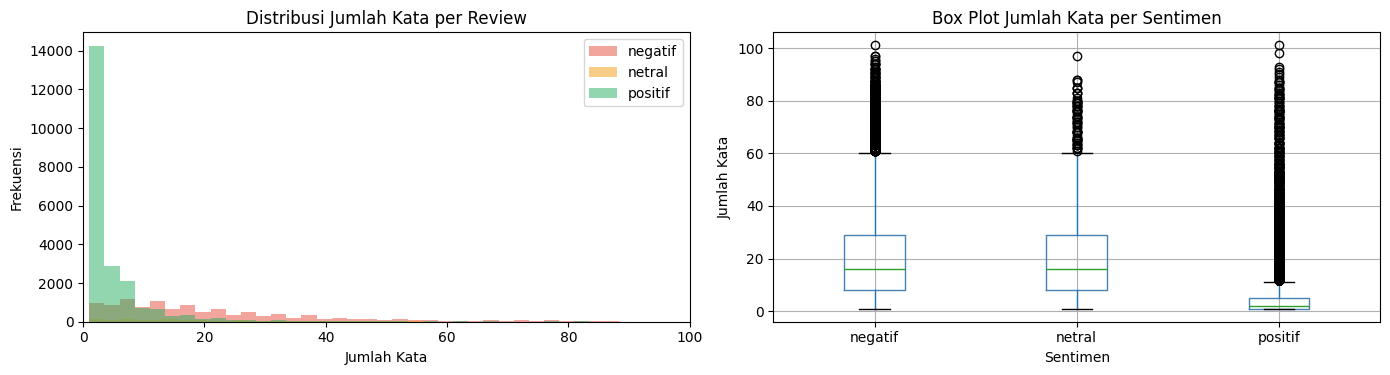


Statistik jumlah kata per label:
           count   mean    std  min  25%   50%   75%    max
label                                                      
negatif  11251.0  21.48  18.52  1.0  8.0  16.0  29.0  101.0
netral    1385.0  21.52  18.28  1.0  8.0  16.0  29.0   97.0
positif  22364.0   5.06   8.45  1.0  1.0   2.0   5.0  101.0


In [28]:
# --- 4.2 Distribusi Panjang Teks ---
df["text_length"] = df["content"].str.len()
df["word_count"]  = df["content"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip(["negatif", "netral", "positif"], colors):
    subset = df[df["label"] == label]["word_count"]
    axes[0].hist(subset, bins=40, alpha=0.5, label=label, color=color)

axes[0].set_title("Distribusi Jumlah Kata per Review")
axes[0].set_xlabel("Jumlah Kata")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].set_xlim(0, 100)

df.boxplot(column="word_count", by="label", ax=axes[1], 
           boxprops=dict(color="steelblue"))
axes[1].set_title("Box Plot Jumlah Kata per Sentimen")
axes[1].set_xlabel("Sentimen")
axes[1].set_ylabel("Jumlah Kata")
plt.suptitle("")

plt.tight_layout()
plt.show()

print("\nStatistik jumlah kata per label:")
print(df.groupby("label")["word_count"].describe().round(2))

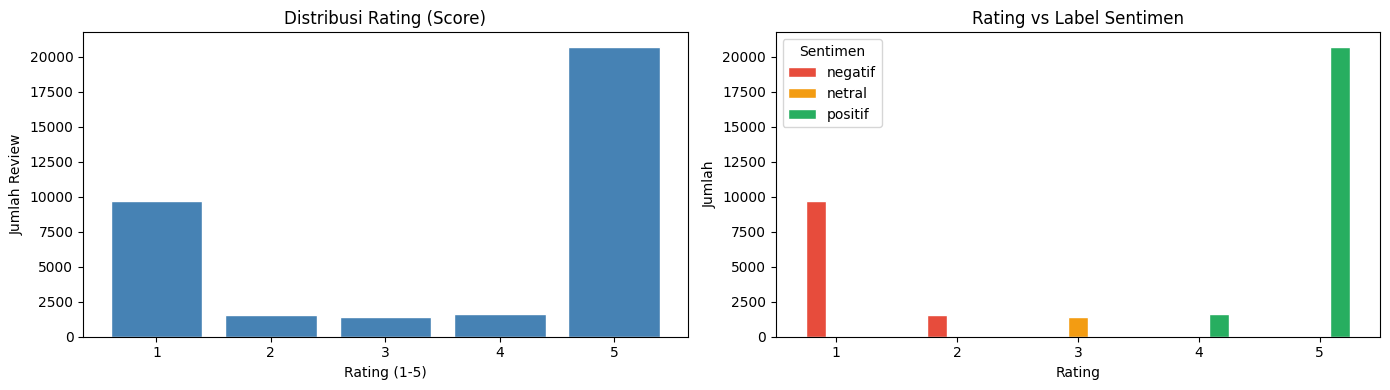

In [29]:
# --- 4.3 Distribusi Rating (Score) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

score_counts = df["score"].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Distribusi Rating (Score)")
axes[0].set_xlabel("Rating (1-5)")
axes[0].set_ylabel("Jumlah Review")
axes[0].set_xticks([1, 2, 3, 4, 5])

# Cross-tabulation score vs label
ct = pd.crosstab(df["score"], df["label"])
ct.plot(kind="bar", ax=axes[1], color=colors, edgecolor="white", rot=0)
axes[1].set_title("Rating vs Label Sentimen")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Jumlah")
axes[1].legend(title="Sentimen")

plt.tight_layout()
plt.show()

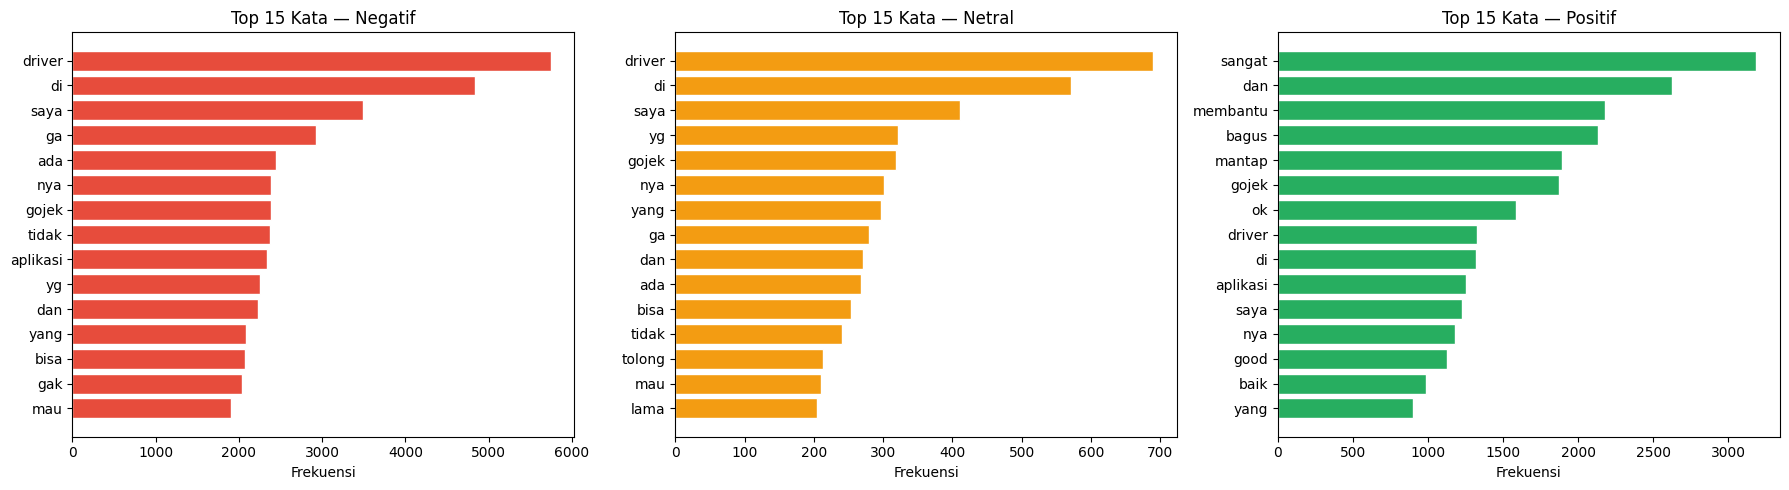

In [30]:
# --- 4.4 Top 20 Kata Paling Umum per Kelas ---
def get_top_words(texts, n=20):
    all_words = " ".join(texts).lower().split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, color) in zip(axes, zip(["negatif", "netral", "positif"], colors)):
    texts = df[df["label"] == label]["content"].tolist()
    top = get_top_words(texts, 15)
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor="white")
    ax.set_title(f"Top 15 Kata — {label.capitalize()}")
    ax.set_xlabel("Frekuensi")

plt.tight_layout()
plt.show()

# 5. Data Preprocessing

Pipeline preprocessing yang diterapkan:

| Langkah | Fungsi | Tujuan |
|---------|--------|--------|
| 1 | `case_folding` | Seragamkan ke huruf kecil |
| 2 | `remove_urls` | Hapus URL/link |
| 3 | `remove_numbers` | Hapus angka |
| 4 | `remove_punctuation` | Hapus tanda baca |
| 5 | `remove_special_characters` | Hapus emoji & simbol |
| 6 | `remove_whitespace` | Normalkan spasi |
| 7 | `repeat_char_norm` | Normalisasi huruf berulang |
| 8 | `normalize_slang` | Ganti slang → baku |
| 9 | `remove_stopwords_custom` | Hapus stopword (sadar-negasi) |
| 10 | `stem_text` | Stemming (Sastrawi + cache) |

In [31]:
# ============================================================
# 5.1 Kamus Normalisasi Slang
# ============================================================
slang_dict = {
    # Negasi
    "ga": "tidak", "gak": "tidak", "gk": "tidak", "ngga": "tidak",
    "nggak": "tidak", "enggak": "tidak", "ngak": "tidak", "tdk": "tidak",
    "tak": "tidak", "kaga": "tidak", "engga": "tidak",
    "blm": "belum", "blom": "belum", "lom": "belum",
    "jgn": "jangan",
    # Intensifier
    "bgt": "banget", "bngt": "banget",
    # Konjungsi umum
    "krn": "karena", "udh": "sudah", "udah": "sudah",
    "bs": "bisa", "yg": "yang", "dg": "dengan", "dgn": "dengan",
    "utk": "untuk", "tp": "tapi", "tpi": "tapi",
    "jd": "jadi", "jga": "juga", "jg": "juga",
    "klo": "kalau", "trs": "terus", "lg": "lagi",
    "aja": "saja", "gmn": "bagaimana", "dpt": "dapat",
    # Ekspresi review
    "kesel": "kesal", "mantul": "mantap", "mantab": "mantap",
    "joss": "bagus", "kece": "bagus", "keren": "bagus",
    "ok": "oke", "okay": "oke", "good": "bagus", "nice": "bagus",
    "bad": "buruk", "jelek": "buruk", "parah": "buruk",
    "lemot": "lambat", "lelet": "lambat", "ribet": "rumit",
    # Domain Gojek
    "drv": "driver", "ojol": "ojek",
    "apk": "aplikasi", "app": "aplikasi",
    "ongkir": "ongkos",
    # Kata ganti
    "sy": "saya", "gw": "saya", "gue": "saya",
    "thx": "terima kasih", "makasih": "terima kasih",
    "min": "admin", "mimin": "admin",
}


# ============================================================
# 5.2 Stopword Sadar-Negasi
# ============================================================
KEEP_WORDS = {
    "tidak", "bukan", "jangan", "belum", "tanpa", "kurang",
    "sangat", "sekali", "banget", "agak", "lebih", "paling",
    "tetapi", "tapi", "namun",
}

stopword_factory  = StopWordRemoverFactory()
default_stopwords = set(stopword_factory.get_stop_words())
custom_stopwords  = default_stopwords - KEEP_WORDS

stemmer = StemmerFactory().create_stemmer()
_stem_cache = {}


# ============================================================
# 5.3 Fungsi-fungsi Preprocessing
# ============================================================
def case_folding(text):
    return text.lower()

def remove_urls(text):
    return re.sub(r"http\S+|www\S+", " ", text)

def remove_numbers(text):
    return re.sub(r"\d+", " ", text)

def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

def remove_special_characters(text):
    return re.sub(r"[^a-z\s]", " ", text)

def remove_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

def repeat_char_norm(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def normalize_slang(text):
    return " ".join(slang_dict.get(tok, tok) for tok in text.split())

def remove_stopwords_custom(text):
    return " ".join(tok for tok in text.split() if tok not in custom_stopwords)

def stem_cached(token):
    if token not in _stem_cache:
        _stem_cache[token] = stemmer.stem(token)
    return _stem_cache[token]

def stem_text(text):
    return " ".join(stem_cached(tok) for tok in text.split())

def clean_text(text):
    """Pipeline preprocessing lengkap."""
    text = case_folding(text)
    text = remove_urls(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    text = remove_whitespace(text)
    text = repeat_char_norm(text)
    text = normalize_slang(text)
    text = remove_stopwords_custom(text)
    text = stem_text(text)
    text = remove_whitespace(text)
    return text


# Smoke test
test_cases = [
    "Bgt jelek bgt!! Drvr nya lemot, ngga rekomen",
    "Aplikasinya OK, tapi promonya udh ga ada lagi",
    "Mantulll bgt, drivernya ramahhhh 😍",
    "tidak bisa login udah 3 hari, CS nya ga respon!",
]
print("=== SMOKE TEST PREPROCESSING ===")
for t in test_cases:
    print(f"IN : {t}")
    print(f"OUT: {clean_text(t)}")
    print()

=== SMOKE TEST PREPROCESSING ===
IN : Bgt jelek bgt!! Drvr nya lemot, ngga rekomen
OUT: banget buruk banget drvr lambat tidak rekomen

IN : Aplikasinya OK, tapi promonya udh ga ada lagi
OUT: aplikasi oke tapi promonya tidak

IN : Mantulll bgt, drivernya ramahhhh 😍
OUT: mantull banget drivernya ramahh

IN : tidak bisa login udah 3 hari, CS nya ga respon!
OUT: tidak login cs tidak respon



In [32]:
# ============================================================
# 5.4 Terapkan Preprocessing ke Seluruh Dataset
# ============================================================
print("Menjalankan preprocessing... (mungkin memakan waktu beberapa menit)")
t0 = time.time()

df["clean_text"] = df["content"].apply(clean_text)

elapsed = time.time() - t0
print(f"Selesai dalam {elapsed:.1f}s")
print(f"Token unik di-cache untuk stemming: {len(_stem_cache):,}")

# Hapus baris yang kosong setelah cleaning
df = df[df["clean_text"].str.len() > 0].copy()
print(f"Shape setelah preprocessing: {df.shape}")

Menjalankan preprocessing... (mungkin memakan waktu beberapa menit)
Selesai dalam 3.5s
Token unik di-cache untuk stemming: 19,906
Shape setelah preprocessing: (34286, 8)


In [33]:
# ============================================================
# 5.5 Verifikasi Hasil Preprocessing
# ============================================================
print("Sample hasil cleaning:")
sample = df[["content", "clean_text", "label"]].sample(10, random_state=SEED)
pd.set_option("display.max_colwidth", 80)
display(sample)

Sample hasil cleaning:


,content,clean_text,label
23377,sempurna,sempurna,positif
32969,syuuukaaa,syuukaa,positif
20441,Solusi bepergian di saat macet,solusi pergi macet,positif
28797,parah..susah cari driver,parahsusah cari driver,negatif
14378,masih sering eror ketika hujan,eror hujan,netral
24666,sangat senang mudah tapi tarifnya agak mahal,sangat senang mudah tapi tarif agak mahal,positif
123,"Untuk tim Gojek yang baik hati dan tidak sombong, sekitar semingguan ini tia...",tim gojek hati tidak sombong minggu pesan go ride drivernya aktif cari prior...,positif
29525,cepat dan akurat,cepat akurat,positif
1132,good,bagus,positif
17864,mantap,mantap,positif


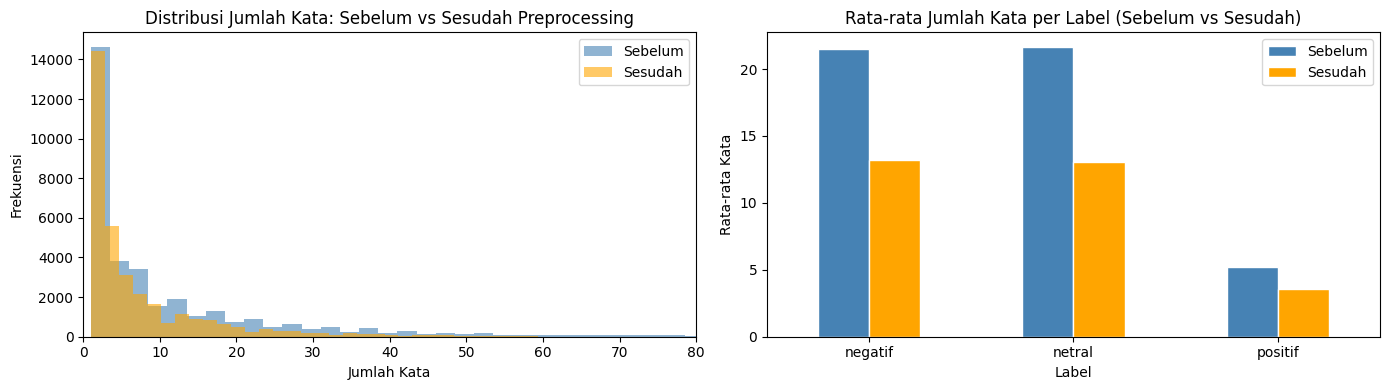


Reduksi rata-rata panjang teks (%): 36.5 %


In [34]:
# ============================================================
# 5.6 Statistik Sebelum vs Sesudah Preprocessing
# ============================================================
df["clean_word_count"] = df["clean_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["word_count"],       bins=40, alpha=0.6, label="Sebelum", color="steelblue")
axes[0].hist(df["clean_word_count"], bins=40, alpha=0.6, label="Sesudah",  color="orange")
axes[0].set_title("Distribusi Jumlah Kata: Sebelum vs Sesudah Preprocessing")
axes[0].set_xlabel("Jumlah Kata")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].set_xlim(0, 80)

# Rata-rata kata per label
comp = df.groupby("label")[["word_count", "clean_word_count"]].mean().round(2)
comp.plot(kind="bar", ax=axes[1], color=["steelblue", "orange"], edgecolor="white", rot=0)
axes[1].set_title("Rata-rata Jumlah Kata per Label (Sebelum vs Sesudah)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Rata-rata Kata")
axes[1].legend(["Sebelum", "Sesudah"])

plt.tight_layout()
plt.show()

print("\nReduksi rata-rata panjang teks (%):",
      round((1 - df["clean_word_count"].mean() / df["word_count"].mean()) * 100, 1), "%")

In [35]:
# ============================================================
# 5.7 Simpan Dataset yang Sudah Dipreprocess
# ============================================================
OUTPUT_PATH = Path("dataset_sentimen_preprocessing/dataset_sentimen_preprocessing.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Kolom yang disimpan untuk training
cols_to_save = ["username", "score", "content", "tanggal", "label", "clean_text"]
cols_to_save = [c for c in cols_to_save if c in df.columns]
df[cols_to_save].to_csv(OUTPUT_PATH, index=False)

print(f"Dataset preprocessing disimpan ke: {OUTPUT_PATH}")
print(f"Shape: {df[cols_to_save].shape}")
print("\nDistribusi label final:")
print(df["label"].value_counts())

Dataset preprocessing disimpan ke: dataset_sentimen_preprocessing\dataset_sentimen_preprocessing.csv
Shape: (34286, 6)

Distribusi label final:
label
positif    21679
negatif    11232
netral      1375
Name: count, dtype: int64
